In [109]:
# imports
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from HWs.week7.hw_w7 import grid_search

# Qeustion 1

Axes(0.125,0.11;0.775x0.77)


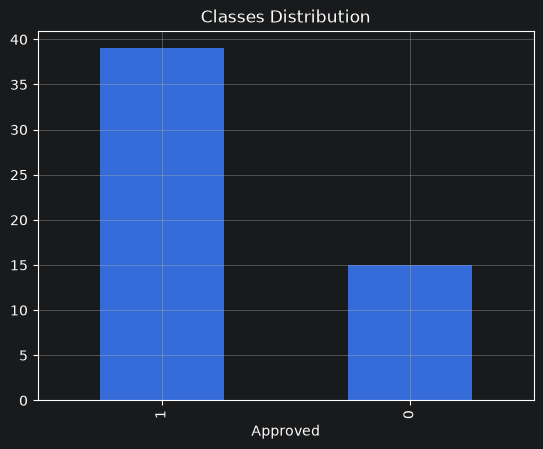

,Income,CreditScore,LoanAmount,Approved
0,30,580,120,0
1,32,585,118,0
2,34,590,115,0
3,35,600,110,0
4,37,605,108,0
5,39,608,107,0
6,40,610,105,0
7,42,615,103,0
8,44,618,102,0
9,45,620,100,0


,Income,CreditScore,LoanAmount,Approved
44,108,812,51,1
45,110,820,50,1
46,112,822,49,1
47,114,825,48,1
48,116,828,47,1
49,118,830,46,1
50,120,832,45,1
51,122,835,44,1
52,124,838,43,1
53,126,840,42,1


,Income,CreditScore,LoanAmount,Approved
count,54.000000,54.000000,54.000000,54.000000
mean,76.055556,723.944444,74.666667,0.722222
std,28.227791,83.636775,22.618243,0.452109
min,30.000000,580.000000,42.000000,0.000000
25%,52.500000,646.250000,55.250000,0.000000
50%,74.500000,735.000000,71.500000,1.000000
75%,99.500000,799.500000,92.750000,1.000000
max,126.000000,840.000000,120.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Income       54 non-null     int64
 1   CreditScore  54 non-null     int64
 2   LoanAmount   54 non-null     int64
 3   Approved     54 non-null     int64
dtypes: int64(4)
memory usage: 1.8 KB


None

In [110]:
loan_data = pd.DataFrame()

loan_data["Income"] = [
    30,
    32,
    34,
    35,
    37,
    39,
    40,
    42,
    44,
    45,
    47,
    49,
    50,
    52,
    54,
    55,
    57,
    59,
    60,
    62,
    64,
    65,
    67,
    69,
    70,
    72,
    74,
    75,
    77,
    79,
    80,
    82,
    84,
    86,
    88,
    90,
    92,
    94,
    96,
    98,
    100,
    102,
    104,
    106,
    108,
    110,
    112,
    114,
    116,
    118,
    120,
    122,
    124,
    126,
]

loan_data["CreditScore"] = [
    580,
    585,
    590,
    600,
    605,
    608,
    610,
    615,
    618,
    620,
    625,
    630,
    640,
    645,
    650,
    660,
    665,
    670,
    680,
    685,
    690,
    700,
    705,
    710,
    720,
    725,
    730,
    740,
    745,
    750,
    760,
    765,
    770,
    775,
    778,
    780,
    785,
    790,
    795,
    798,
    800,
    803,
    806,
    810,
    812,
    820,
    822,
    825,
    828,
    830,
    832,
    835,
    838,
    840,
]

loan_data["LoanAmount"] = [
    120,
    118,
    115,
    110,
    108,
    107,
    105,
    103,
    102,
    100,
    98,
    97,
    95,
    93,
    92,
    90,
    89,
    88,
    85,
    84,
    83,
    80,
    79,
    78,
    75,
    74,
    73,
    70,
    69,
    68,
    65,
    64,
    63,
    62,
    61,
    60,
    59,
    58,
    57,
    56,
    55,
    54,
    53,
    52,
    51,
    50,
    49,
    48,
    47,
    46,
    45,
    44,
    43,
    42,
]

loan_data["Approved"] = [
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
]
print(loan_data["Approved"].value_counts().plot(kind="bar"))
plt.title("Classes Distribution")
plt.grid()
plt.show()
display(loan_data.head(10))
display(loan_data.tail(10))
display(loan_data.describe())
display(loan_data.info())

Accuracy: 100.0%


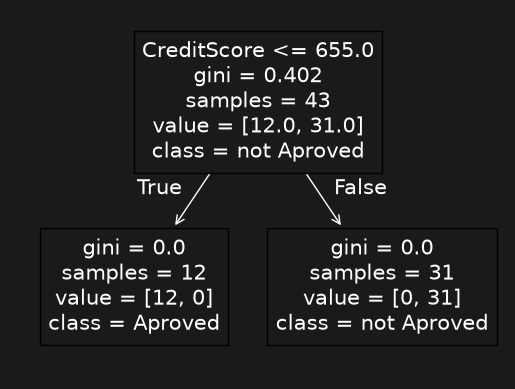

new_customer: [1]


In [111]:
# split data to Train and test set
X_train, X_test, y_train, y_test = train_test_split(
    loan_data.iloc[:, :-1].to_numpy(),
    loan_data.iloc[:, -1].to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=loan_data.iloc[:, -1],
)

tree = DecisionTreeClassifier()

fitted_tree = tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100}%")
feature_names = loan_data.columns[:-1].tolist()
plot_tree(
    fitted_tree, feature_names=feature_names, class_names=["Aproved", "not Aproved"]
)
plt.show()

new_customer = [[68, 710, 78]]
new_pred = tree.predict(new_customer)
print(f"new_customer: {new_pred}")

# Question 2

In [112]:
train_acc = accuracy_score(y_train, tree.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print(f"{"Train Accuracy":<15}:{train_acc*100}%")
print(f"{"Test Accuracy":<15}:{test_acc*100}%\n{"-"*23}")
tree_3 = DecisionTreeClassifier(max_depth=3)
tree_3.fit(X_train, y_train)
y_pred3 = tree_3.predict(X_test)
train_acc = accuracy_score(y_train, tree_3.predict(X_train))
test_acc = accuracy_score(y_test, y_pred3)
print(f"max depth = 3\n{"Train Accuracy":<15}:{train_acc*100}%")
print(f"{"Test Accuracy":<15}:{test_acc*100}%")

Train Accuracy :100.0%
Test Accuracy  :100.0%
-----------------------
max depth = 3
Train Accuracy :100.0%
Test Accuracy  :100.0%


# Question 3

In [113]:
customer_data = pd.DataFrame()
customer_data["AnnualIncome"] = [
    15,
    18,
    20,
    22,
    25,
    28,
    30,
    32,
    35,
    38,
    40,
    42,
    45,
    48,
    50,
    52,
    55,
    58,
    60,
    62,
    65,
    68,
    70,
    72,
    75,
    78,
    80,
    82,
    85,
    88,
    90,
    95,
    100,
    105,
    110,
    115,
    120,
    125,
    130,
    135,
    140,
    145,
    150,
    160,
    170,
]
customer_data["SpendingScore"] = [
    90,
    85,
    80,
    82,
    78,
    75,
    72,
    70,
    68,
    65,
    62,
    60,
    58,
    55,
    52,
    50,
    48,
    45,
    42,
    40,
    38,
    35,
    32,
    30,
    28,
    25,
    23,
    20,
    18,
    15,
    12,
    10,
    8,
    15,
    18,
    20,
    22,
    25,
    28,
    30,
    32,
    35,
    38,
    40,
    42,
]
display(customer_data.head())
customer_data.describe()

,AnnualIncome,SpendingScore
0,15,90
1,18,85
2,20,80
3,22,82
4,25,78


,AnnualIncome,SpendingScore
count,45.000000,45.000000
mean,76.177778,42.577778
std,42.107162,22.778068
min,15.000000,8.000000
25%,42.000000,25.000000
50%,70.000000,38.000000
75%,105.000000,60.000000
max,170.000000,90.000000


In [114]:
k_means = KMeans(n_clusters=3,random_state=42)
k_means.fit(customer_data)
customer_data["Cluster"] = k_means.predict(customer_data)
centroids = k_means.cluster_centers_


,AnnualIncome,SpendingScore,Cluster
0,15,90,2
1,18,85,2
2,20,80,2
3,22,82,2
4,25,78,2


,AnnualIncome,SpendingScore,Cluster
40,140,32,1
41,145,35,1
42,150,38,1
43,160,40,1
44,170,42,1


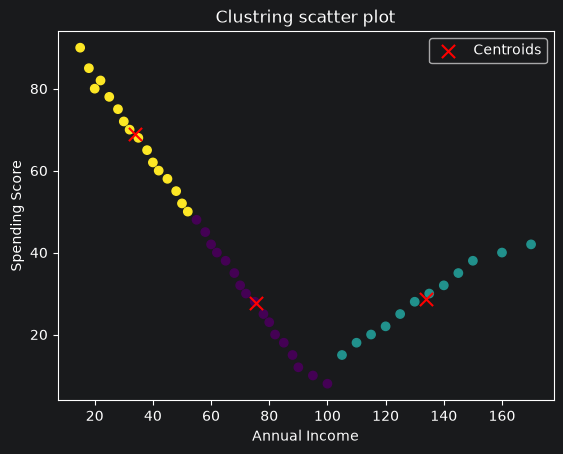

In [115]:
display(customer_data.head(5))
display(customer_data.tail(5))
plt.scatter(customer_data["AnnualIncome"], customer_data["SpendingScore"],c=customer_data['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1],c="red",marker="x",s=90,label="Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.title("Clustring scatter plot")
plt.show()

,AnnualIncome,SpendingScore,Cluster
0,15,90,0
1,18,85,0
2,20,80,0
3,22,82,0
4,25,78,0


,AnnualIncome,SpendingScore,Cluster
40,140,32,1
41,145,35,1
42,150,38,1
43,160,40,1
44,170,42,1


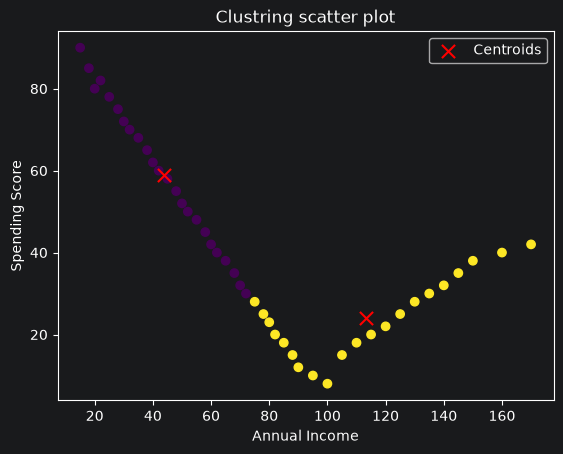

In [116]:
k_means = KMeans(n_clusters=2,random_state=42)
k_means.fit(customer_data)
customer_data["Cluster"] = k_means.predict(customer_data)
centroids = k_means.cluster_centers_

display(customer_data.head(5))
display(customer_data.tail(5))
plt.scatter(customer_data["AnnualIncome"], customer_data["SpendingScore"],c=customer_data['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1],c="red",marker="x",s=90,label="Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.title("Clustring scatter plot")
plt.show()


,AnnualIncome,SpendingScore,Cluster
0,15,90,2
1,18,85,2
2,20,80,2
3,22,82,2
4,25,78,2


,AnnualIncome,SpendingScore,Cluster
40,140,32,1
41,145,35,1
42,150,38,1
43,160,40,1
44,170,42,1


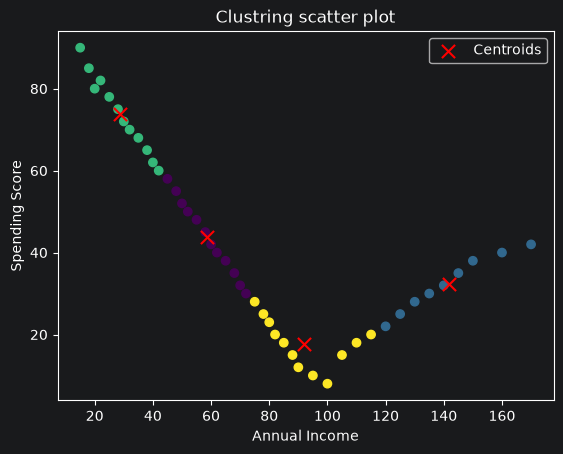

In [117]:
k_means = KMeans(n_clusters=4,random_state=42)
k_means.fit(customer_data)
customer_data["Cluster"] = k_means.predict(customer_data)
centroids = k_means.cluster_centers_

display(customer_data.head(5))
display(customer_data.tail(5))
plt.scatter(customer_data["AnnualIncome"], customer_data["SpendingScore"],c=customer_data['Cluster'])
plt.scatter(centroids[:, 0], centroids[:, 1],c="red",marker="x",s=90,label="Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.title("Clustring scatter plot")
plt.show()

# Extra

In [7]:
import pandas as pd
df_1 = pd.read_csv(r"E:\Maktab-145\Datasets\podcast_episodes.csv")
df_2 = pd.read_csv(r"E:\Maktab-145\Datasets\podcast_listeners.csv")
display(df_1.head())
df_1.info()

,episode_id,episode_length_min,genre,num_ads,guest_rating,host_experience_years,avg_listen_minutes
0,EP001,42.3,True Crime,4,2.7,4,36.6
1,EP002,56.1,Tech,4,4.0,4,38.4
2,EP003,16.6,True Crime,4,4.9,9,20.1
3,EP004,58.2,Fiction,0,3.9,10,46.4
4,EP005,37.4,Comedy,3,4.3,8,27.7


,listener_id,hours_per_week,num_genres_followed,num_episodes_completed,skip_rate_percent,days_since_signup,is_premium
0,L0001,3.2,3,7.0,74.0,435,1
1,L0002,1.7,3,7.0,100.0,189,0
2,L0003,4.0,5,4.0,70.5,860,1
3,L0004,5.1,3,10.0,57.9,558,1
4,L0005,2.0,6,4.0,86.2,490,1


<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   episode_id             220 non-null    str    
 1   episode_length_min     220 non-null    float64
 2   genre                  220 non-null    str    
 3   num_ads                220 non-null    int64  
 4   guest_rating           220 non-null    float64
 5   host_experience_years  220 non-null    int64  
 6   avg_listen_minutes     220 non-null    float64
dtypes: float64(3), int64(2), str(2)
memory usage: 12.2 KB


# Regression task

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
Xtrain,Xtest,ytrain,ytest = train_test_split(df_1.loc[:,["episode_length_min","num_ads","guest_rating","host_experience_years"]],df_1.iloc[:,-1],test_size=0.2,random_state=42)
linear = LinearRegression()
linear.fit(Xtrain,ytrain)

ypred = linear.predict(Xtest)
mae = mean_absolute_error(ytest,ypred)
mse = mean_squared_error(ytest,ypred)
r2 = r2_score(ytest,ypred)

print(f"MAE: {mae:.3f}, RMSE: {np.sqrt(mse):.3f},MSE: {(mse):.3f}, R2: {r2:.3f}")

MAE: 3.941, RMSE: 4.785,MSE: 22.898, R2: 0.657


In [16]:
print(linear.coef_)
linear.intercept_

[ 0.5723725  -1.20524878  1.96226459  0.25294765]


np.float64(4.01591296719182)

# Classification

,listener_id,hours_per_week,num_genres_followed,num_episodes_completed,skip_rate_percent,days_since_signup,is_premium
0,L0001,3.2,3,7.0,74.0,435,1
1,L0002,1.7,3,7.0,100.0,189,0
2,L0003,4.0,5,4.0,70.5,860,1
3,L0004,5.1,3,10.0,57.9,558,1
4,L0005,2.0,6,4.0,86.2,490,1


<Axes: xlabel='is_premium'>

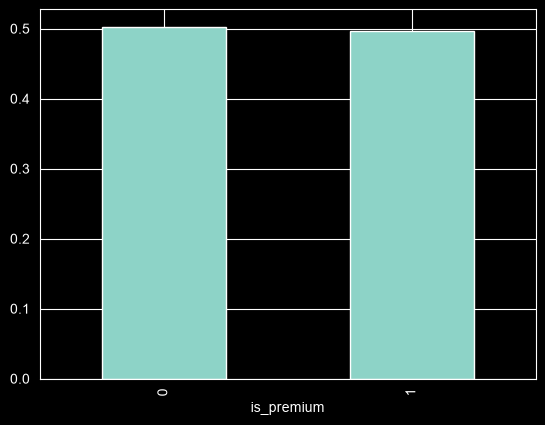

In [37]:
display(df_2.head())
display(df_2.iloc[:,-1].value_counts(normalize=True).plot(kind='bar'))

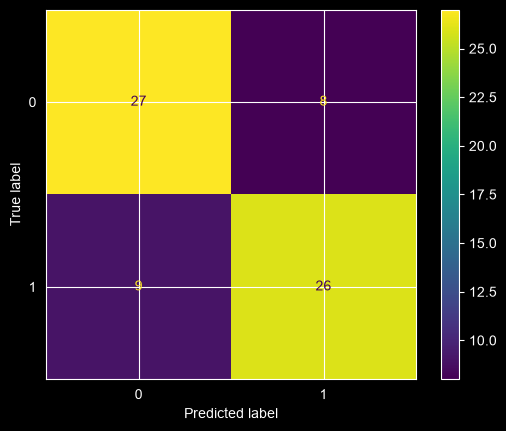

Precision 0.765, Recall 0.743, F1 0.754, Accuracy 0.757


In [38]:
Xtrain,Xtest,ytrain,ytest = train_test_split(df_2.iloc[:,2:-1],df_2.iloc[:,-1],test_size=0.2,random_state=42,stratify=df_2.iloc[:,-1])

from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
# import Decision boundry from sklearn
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
logreg = LogisticRegression()

logreg.fit(Xtrain,ytrain)
ypred = logreg.predict(Xtest)

cm = confusion_matrix(ytest,ypred)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=logreg.classes_)
dsp.plot()
plt.show()
tn,fp,fn,tp = cm.ravel()
precision = tp / (tp + fp +1e-7)
recall = tp / (tp + fn +1e-7)
f1 = 2 * precision * recall / (precision + recall + 1e-7)
accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-7)
print(f"Precision {precision:.3f}, Recall {recall:.3f}, F1 {f1:.3f}, Accuracy {accuracy:.3f}")



In [66]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=None,random_state=42)
tree.fit(Xtrain,ytrain)
ypred_tree = tree.predict(Xtest)
print(f"acc train {tree.score(Xtrain,ytrain):.3f}")
print(f"acc test {tree.score(Xtest,ytest):.3f}")

tree_3 = DecisionTreeClassifier(max_depth=3,random_state=42)
tree_3.fit(Xtrain,ytrain)
ypred_tree_3 = tree_3.predict(Xtest)
print(f"acc train {tree_3.score(Xtrain,ytrain):.3f}")
print(f"acc test {tree_3.score(Xtest,ytest):.3f}")

acc train 1.000
acc test 0.700
acc train 0.739
acc test 0.714


In [75]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from sklearn.metrics import f1_score
tree_raw = DecisionTreeClassifier()
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
grid_search = GridSearchCV(
    cv=skf,
    estimator=tree_raw,
    param_grid={"max_depth":[1,3,5,10],"random_state":[10,20,42,50]},
    scoring="f1"
)
grid_search.fit(Xtrain,ytrain)
print(grid_search.best_params_)
best_model = grid_search.best_estimator_
print(grid_search.best_score_)
best_pred = best_model.predict(Xtest)

f1_score(ytest,best_pred)

{'max_depth': 3, 'random_state': 10}
0.6476957844415472


0.7058823529411765

# Clustering

In [42]:
X = df_2.loc[:,['num_genres_followed','hours_per_week']]
X.head()

,num_genres_followed,hours_per_week
0,3,3.2
1,3,1.7
2,5,4.0
3,3,5.1
4,6,2.0


[7.02837838 2.63361345 2.48726115] [4. 2. 6.]


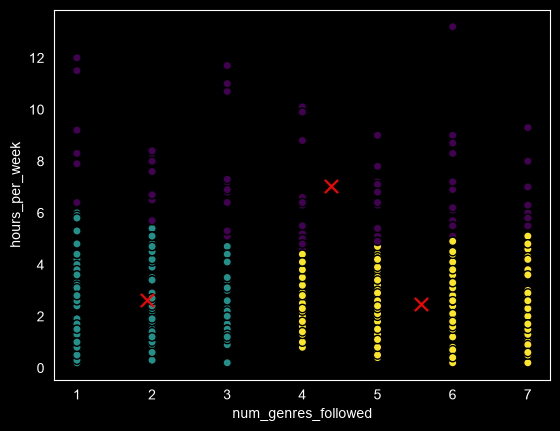

In [62]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters=3,random_state=42)
k_means.fit(X)

clusters = k_means.predict(X)
centroids = k_means.cluster_centers_
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=clusters,cmap='viridis', edgecolor='k')
plt.scatter(centroids[:,0],centroids[:,1],c="red",marker="x",s=90)
plt.xlabel("num_genres_followed")
plt.ylabel("hours_per_week")
plt.grid(False)
print(centroids[:,1],np.round(centroids[:,0]))